In [2]:
!pip install pandas numpy nltk textblob scikit-learn matplotlib

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
df = pd.read_csv("Student Feedback.csv")

In [6]:
print("Dataset loaded successfully!")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

Dataset loaded successfully!
  Student_ID Department            Subject  \
0       S001        MCA                NLP   
1       S002        MCA               DBMS   
2       S003        MCA             Python   
3       S004        MCA  Computer Networks   
4       S005        MCA   Machine Learning   

                                            Feedback  
0  The teacher explains concepts very clearly and...  
1  The classes are too fast and difficult to follow.  
2          I am very happy with the teaching method.  
3  There should be more practical laboratory sess...  
4  The teacher provides useful notes and explanat...  

Dataset Shape:
(60, 4)

Columns:
Index(['Student_ID', 'Department', 'Subject', 'Feedback'], dtype='object')


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Student_ID    0
Department    0
Subject       0
Feedback      0
dtype: int64


In [8]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

df['Cleaned_Feedback'] = df['Feedback'].apply(preprocess_text)

print(df[['Feedback', 'Cleaned_Feedback']].head(10))

                                            Feedback  \
0  The teacher explains concepts very clearly and...   
1  The classes are too fast and difficult to follow.   
2          I am very happy with the teaching method.   
3  There should be more practical laboratory sess...   
4  The teacher provides useful notes and explanat...   
5  The assignments are too difficult and time con...   
6  The subject is interesting and the teacher enc...   
7       More real world examples should be provided.   
8           The practical sessions are very helpful.   
9               The classroom activities are boring.   

                                    Cleaned_Feedback  
0  teacher explains concepts clearly uses good ex...  
1                      classes fast difficult follow  
2                              happy teaching method  
3                      practical laboratory sessions  
4         teacher provides useful notes explanations  
5               assignments difficult time consuming 

In [9]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Feedback'].apply(get_sentiment)

print(df[['Feedback', 'Sentiment']].head(15))

                                             Feedback Sentiment
0   The teacher explains concepts very clearly and...  Positive
1   The classes are too fast and difficult to follow.  Negative
2           I am very happy with the teaching method.  Positive
3   There should be more practical laboratory sess...  Positive
4   The teacher provides useful notes and explanat...  Positive
5   The assignments are too difficult and time con...  Negative
6   The subject is interesting and the teacher enc...  Positive
7        More real world examples should be provided.  Positive
8            The practical sessions are very helpful.  Positive
9                The classroom activities are boring.  Negative
10   The teacher explains difficult topics patiently.  Negative
11          There is not enough time to clear doubts.  Positive
12  I am satisfied with the teaching and learning ...  Positive
13  The lectures are informative but sometimes too...   Neutral
14            More coding exercises woul

In [10]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['Polarity'] = df['Feedback'].apply(get_polarity)

print(df[['Feedback', 'Polarity', 'Sentiment']].head(10))

                                            Feedback  Polarity Sentiment
0  The teacher explains concepts very clearly and...  0.415000  Positive
1  The classes are too fast and difficult to follow. -0.150000  Negative
2          I am very happy with the teaching method.  1.000000  Positive
3  There should be more practical laboratory sess...  0.500000  Positive
4  The teacher provides useful notes and explanat...  0.300000  Positive
5  The assignments are too difficult and time con... -0.500000  Negative
6  The subject is interesting and the teacher enc...  0.166667  Positive
7       More real world examples should be provided.  0.350000  Positive
8           The practical sessions are very helpful.  0.200000  Positive
9               The classroom activities are boring. -1.000000  Negative


Sentiment
Positive    42
Negative     9
Neutral      9
Name: count, dtype: int64


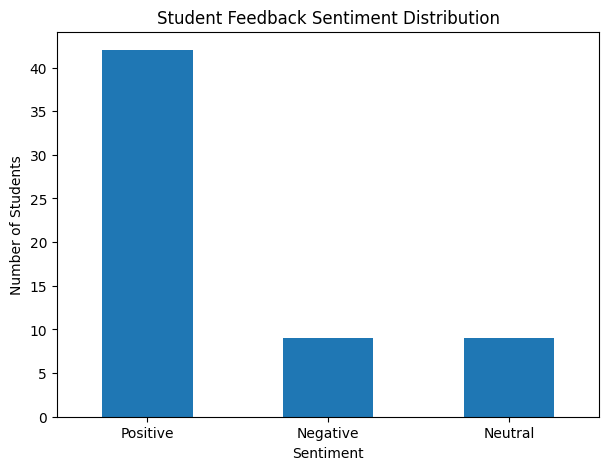

In [11]:
sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)
plt.figure(figsize=(7,5))

sentiment_counts.plot(kind='bar')

plt.title("Student Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

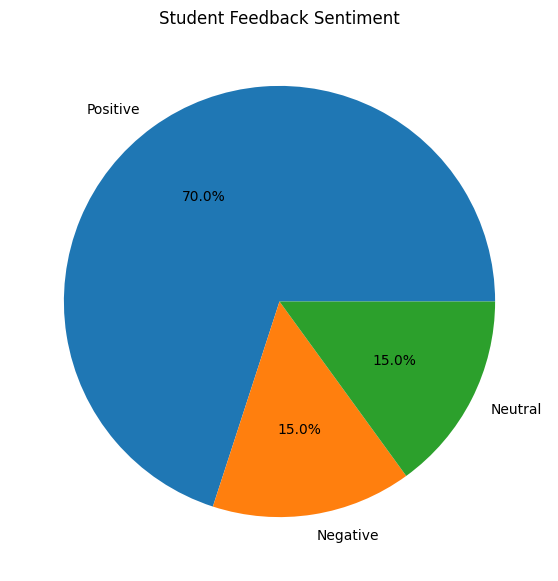

In [12]:
plt.figure(figsize=(7,7))

df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Student Feedback Sentiment")
plt.ylabel("")

plt.show()

In [13]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

tfidf_matrix = vectorizer.fit_transform(df['Cleaned_Feedback'])

words = vectorizer.get_feature_names_out()

scores = tfidf_matrix.sum(axis=0).A1

tfidf_words = pd.DataFrame({
    'Word': words,
    'Score': scores
})

tfidf_words = tfidf_words.sort_values(
    by='Score',
    ascending=False
)

print(tfidf_words)

           Word     Score
16      teacher  8.953518
13    practical  6.916547
17     teaching  5.662077
7      examples  4.298713
14     sessions  3.600024
19       useful  3.557362
15      subject  3.541729
6     difficult  3.519457
9      explains  3.515790
10  interesting  3.341766
0    activities  3.261974
1   assignments  3.224482
12     lectures  3.000000
18   understand  2.830860
3     classroom  2.750956
5      concepts  2.621273
2       classes  2.579326
8    experience  2.095549
11     learning  2.048561
4       clearly  1.729857


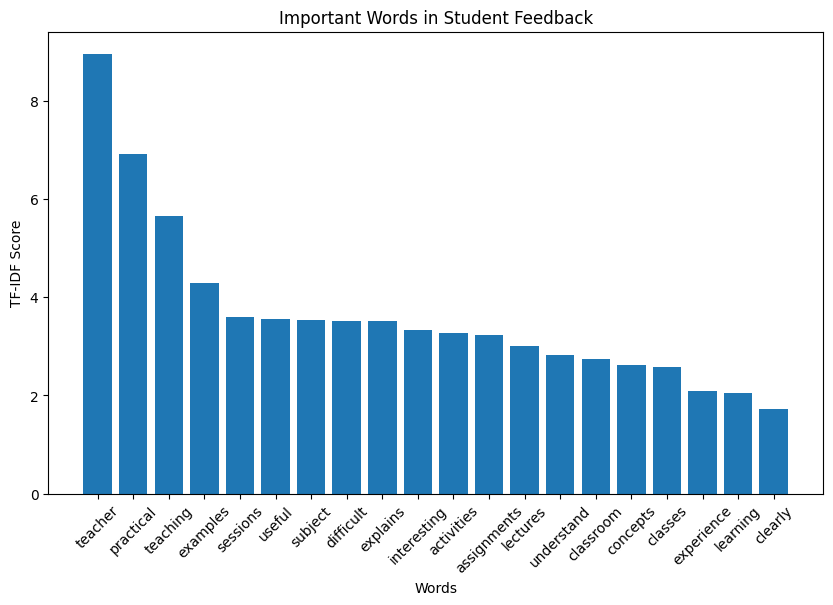

In [14]:
plt.figure(figsize=(10,6))

plt.bar(
    tfidf_words['Word'],
    tfidf_words['Score']
)

plt.title("Important Words in Student Feedback")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")

plt.xticks(rotation=45)

plt.show()

In [15]:
negative_feedback = df[
    df['Sentiment'] == 'Negative'
]

print("Number of Negative Feedback:", len(negative_feedback))

print("\nNegative Feedback:")
for feedback in negative_feedback['Feedback']:
    print("-", feedback)

Number of Negative Feedback: 9

Negative Feedback:
- The classes are too fast and difficult to follow.
- The assignments are too difficult and time consuming.
- The classroom activities are boring.
- The teacher explains difficult topics patiently.
- The concepts are difficult to understand without practical examples.
- The subject is difficult and needs more examples.
- The classes are sometimes boring.
- The concepts are difficult to understand.
- The lectures are sometimes too long.


In [16]:
negative_text = ' '.join(
    negative_feedback['Cleaned_Feedback']
)

words = negative_text.split()

word_counts = Counter(words)

common_words = word_counts.most_common(15)

print("Common Words in Negative Feedback:")

for word, count in common_words:
    print(word, ":", count)

Common Words in Negative Feedback:
difficult : 6
classes : 2
boring : 2
concepts : 2
understand : 2
examples : 2
sometimes : 2
fast : 1
follow : 1
assignments : 1
time : 1
consuming : 1
classroom : 1
activities : 1
teacher : 1


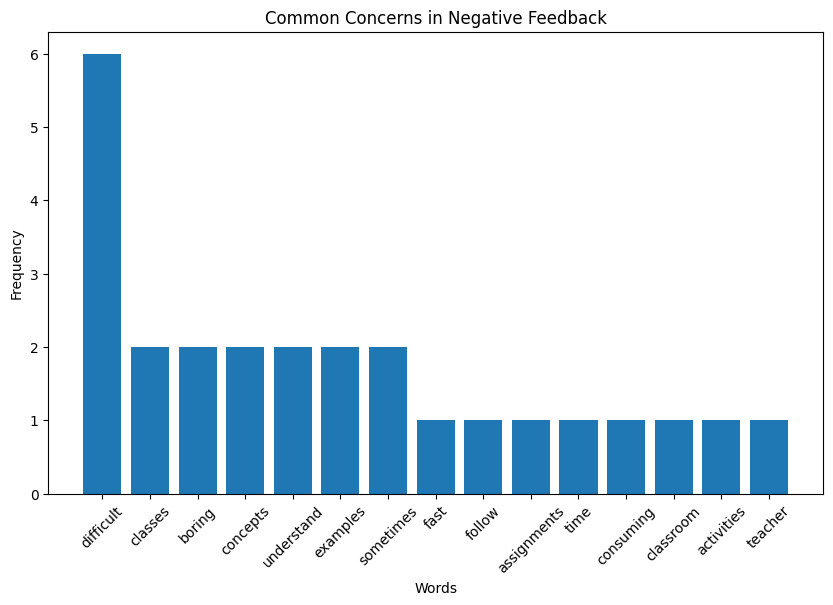

In [17]:
common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(10,6))

plt.bar(
    common_df['Word'],
    common_df['Frequency']
)

plt.title("Common Concerns in Negative Feedback")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [18]:
department_sentiment = pd.crosstab(
    df['Department'],
    df['Sentiment']
)

print(department_sentiment)

Sentiment   Negative  Neutral  Positive
Department                             
BBA                2        2        12
BCA                2        4        14
MCA                5        3        16


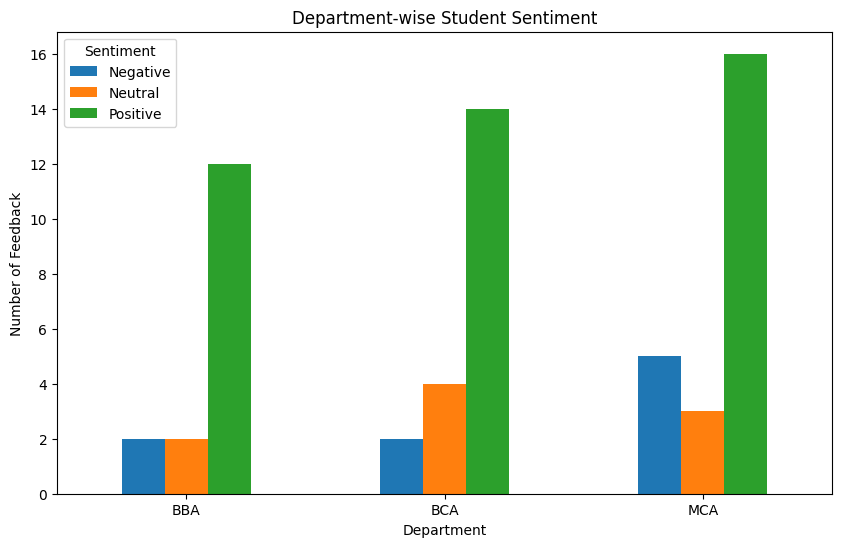

In [19]:
department_sentiment.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Department-wise Student Sentiment")
plt.xlabel("Department")
plt.ylabel("Number of Feedback")
plt.xticks(rotation=0)

plt.show()

Sentiment             Negative  Neutral  Positive
Subject                                          
Computer Networks            2        0         5
DBMS                         2        3         3
Finance                      1        1         3
Human Resource               0        1         4
Java                         1        1         5
Machine Learning             2        0         2
Marketing                    1        0         5
NLP                          0        1         4
Python                       0        2         7
Software Engineering         0        0         4


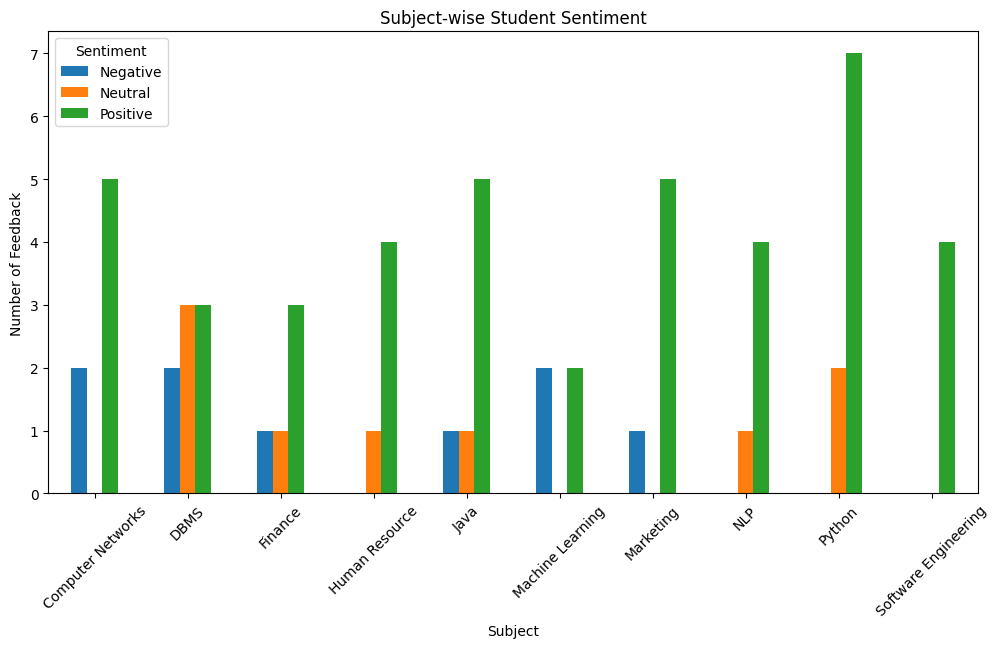

In [20]:
subject_sentiment = pd.crosstab(
    df['Subject'],
    df['Sentiment']
)

print(subject_sentiment)
subject_sentiment.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Subject-wise Student Sentiment")
plt.xlabel("Subject")
plt.ylabel("Number of Feedback")

plt.xticks(rotation=45)

plt.show()

In [21]:
df.to_csv(
    "student_feedback_analysis_results.csv",
    index=False
)

print("Analysis completed successfully!")
print("Results saved as student_feedback_analysis_results.csv")

Analysis completed successfully!
Results saved as student_feedback_analysis_results.csv
